<div style="display:flex; justify-content:center; align-items:center; margin:25px 0;">
    
![jupyter](img/logo.png)

</div>

<div align="center">

# **Neuronas Convolucionales**

</div>


<div style="display:flex; justify-content:center; align-items:center; margin:25px 0;">
    
![jupyter](img/python.png)

</div>

<div align="center">
    
## **Nombre**: ***Adriel Bedoya***

</div>

## ¿Qué es una CNN?

También conocida como "Convolutional Neural Network", es una arquitectura de aprendizaje profundo diseñada para procesar datos que tienen estructura de cuadrícula como:
- Imágenes (2D)
- Videos (3D)

A diferencia de las redes densas o totalmente conectadas, las CNN aprovechan la estructura espacial de los datos mediante el uso de operaciones de convolución, reduciendo de manera importante la cantidad de parámetros necesarios y permite que el modelo aprenda características jerárquicas, desde bordes y texturas en las primeras capas hasta objetos completos en las capas más profundas

La motivación principal que hubo para usar estas neuronas en vez de las redes totalmente conectadas, fue por el problema de la dimensionalidad. Por ejemplo, una imagen a color de tamaño 256 por 256 píxeles tiene 196,608 valores de entrada (256×256×3 canales). Si conectamos esta entrada a una primera capa oculta con 1,000 neuronas, ya tendríamos aproximadamente 196 millones de parámetros solo en esa primera capa, sin contar las capas siguientes. Esta cantidad masiva de parámetros provoca dos problemas graves: primero, se requiere una cantidad de datos igualmente masiva para evitar el sobreajuste; segundo, el entrenamiento sería extremadamente lento y requeriría una memoria prohibitiva. Además, las redes densas pierden completamente la estructura espacial de la imagen, ya que al aplanar la entrada en un vector unidimensional se destruyen las relaciones de vecindad entre píxeles que son fundamentales para el reconocimiento visual.

El ser humano tuvo la inspiración proveniente de los estudios sobre la corteza visual primera (área V1) del cerebro de los mamíferos. Los neurocientíficos **Hubel y Wiesel** descubrieron en la década de 1960 que existen neuronas en esta región que solo responden a estímulos visuales dentro de pequeñas regiones específicas del campo visual, llamadas **campos receptivos**. Además, descubrieron que algunas neuronas se activan selectivamente ante bordes con orientaciones particulares (horizontales, verticales, diagonales), mientras que otras responden a patrones más complejos. Estas neuronas están organizadas de manera jerárquica: las señales de los campos receptivos simples se combinan para formar campos receptivos más complejos en capas superiores. Las CNN imitan esta organización mediante las capas convolucionales (básicamente actúan como campos receptivos) y las capas de pooling (combinan información de regiones vecinas)

<div style="display:flex; justify-content:center; align-items:center; margin:25px 0;">
    
![Neuronas Convolucionales](cnn/CNN.png)

</div>

## ¿Por qué las CNN son más eficientes que las redes densas?

Su eficiencia se basa en 3 principios fundamentales:

1. Parámetros Compartidos
2. Conectividad Local
3. Submuestreo

### 1. Parámetro Compartido
Significa que un mismo filtro o kernel se aplica a todas las regiones de la imagen, lo que reduce drásticamente el número de pesos por aprender. Por ejemplo, si tenemos un filtro de 3x3 aplicado a una imagen de 256x256, solo necesitamos 9 pesos (más el sesgo), mientras que una capa densa necesitaría más de 65,000 pesos para la misma imagen.

### 2. Conectividad Local
Implica que cada neurona en la capa de salida solo se conecta a una pequeña región de la entrada (que sería el campo receptivo), en lugar de conectarse a todas las entradas. Esto refleja la idea de que los px cercanos están más correlacionados que los px lejanos

### 3. Submuestreo (mediante capas de pooling)
Reduce la resolución espacial de las representaciones, lo que disminuye la sensibilidad a pequeñas traslaciones y rotaciones, también reduce la cantidad de cómputo necesario para las siguientes capas

<div style="display:flex; justify-content:center; align-items:center; margin:25px 0;">
    
![Neuronas Convolucionales](cnn/CNN2.jpg)

</div>

## Operaciones Básicas de una CNN

### La Operación de Convolución

La operación fundamental en una CNN es la convolución 2D. Matemáticamente, para una imagen de entrada "I"(matriz de px) y un filtro o kernel "K"(una matriz más pequeña de pesos aprendibles), la convolución en la posición (i, j) se define como:

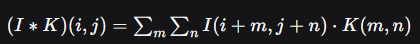

En cristiano, lo que hace esta operación es deslizar el filtro sobre la imagen, en cada posición, va a multiplicar los valores del filtro por los valores de la imagen que están debajo, sumando todos esos productos para producir un único número en la posición correspondiente de la salida. El resultado de aplicar un filtro a toda la imagen se llama "Mapa de Características/feature map"

Existen varios parámetros que controlan cómo se realiza esta convolución:

1. Es el tamaño del kernel o filtro, que típicamente suele ser de 3x3 o 5x5, aunque también se usan otros tamaños. Un kernel más pequeño captura detalles finos, mientras que uno más grande captura patrones más amplios.
2. Es el stride o paso, que indica cuántos px se desplaza por el filtro en cada movimiento. Un stride de 1 significa que el filtro se mueve de uno en uno, produciendo una salida de tamaño similar a la entrada; un stride de 2 produce una salida más pequeña
3. Es el padding o relleno, consiste en agregar filas y columnas de ceros alrededor de la imagen de entrada. El padding "same" agrega suficientes ceros para que la salida tenga exactamente el mismo tamaño que la entrada, mientras que el padding "valid" no agrega ceros, po lo que la salida es más pequeña

La fórmula para calcular el tamaño de salida después de la convolución es:

![image.png](cnn/formula.png)

Donde W es el tamaño de la entrada, K es el tamaño del kernel, P es la cantidad de padding (en cada lado) y S es el stride. El símbolo ⌊⌋ indica la operación de redondeo hacia abajo (floor). Por ejemplo, si tenemos una imagen de 32×32, un kernel de 3×3, padding de 1 y stride de 1, el tamaño de salida será (32 - 3 + 2×1)/1 + 1 = 32, es decir, se mantiene el tamaño. Si el stride fuera 2, el tamaño sería (32 - 3 + 2)/2 + 1 = 31/2 + 1 = 15.5 + 1 = 16.5, redondeando hacia abajo da 16.

Es importante entender que en una capa convolucional típica no se usa un solo filtro, sino varios. Cada filtro aprende a detectar un patrón diferente: bordes horizontales, bordes verticales, esquinas, texturas, etc. Si tenemos, por ejemplo, 32 filtros, la salida de la capa será un tensor de tres dimensiones: alto, ancho y 32 canales (cada canal es el mapa de características de un filtro diferente). Por esta razón, en las arquitecturas modernas, el número de filtros suele aumentar a medida que avanzamos hacia capas más profundas, mientras que las dimensiones espaciales (alto y ancho) disminuyen mediante el pooling.

### Función de Activación ReLU

Después de cada CNN, se aplica la función de activación no lineal. La más utilizada en las CNN es ReLU (Rectified Linear Unit), cuya definición es:

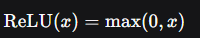

Esta función devuelve el valor de entrada si es positivo y devuelve cero en caso que sea negativo. La popularidad de ReLU se debe a varias ventajas sobre funciones como la sigmoide o la tangente hiperbólica.

- ReLU no sufre del problema de desvanecimiento del gradiente (vanishing gradient) para valores positivos, ya que su derivada es constante. Esto permite que el gradiente fluya sin atenuarse a través de muchas capas facilitando el entrenamiento de redes profundas

- Es computacionalmente muy barata, solo requiere una comparación con cero, mientras que la sigmoide requiere exponencialmente costosas

- Produce activaciones dispersas: aproximadamente la mitad de las neuronas devuelven cero, lo que introduce una regularización neuronal

Pero no todo es color de rosa, ReLU también tiene una desventaja fuerte que es la **"Muerte de las neuronas"**: si una neurona recibe valores negativos consistentemente, su salida será siempre cero y su gradiente será también cero, por lo que nunca volverá actualizarse. Para resolver este problema, se propuso variantes como **Leaky ReLU**, que permite un pequeño flujo negativo

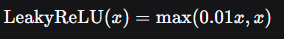

Otra variante sería ELU (Exponential Linear Unit), satura un valor negativo para entradas muy negativas, lo que ayuda a centrar activaciones alrededor de cero

## Operación de Pooling (Submuestreo)

Pooling es una operación que reduce la dimensionalidad espacial de los mapas de características, manteniendo la información más relevante. La forma más común es el max pooling, que divide la entrada en ventanas rectangulares (generalmente de 2x2) y, para cada ventana, se queda con el valor máximo. Esto tiene el efecto de hacer la representación invariante a pequeñas traslaciones:

Si un patrón se desplaza ligeramente dentro de la ventana, el máximo seguirá siendo el mismo. Además, el pooling reduce de manera muy importante el tamaño de los mapas de características, lo que disminuye la cantidad de parámetros en las capas siguientes y ayuda a controlar el sobre-ajuste

#### Ejemplo
Si tenemos un mapa de características de 32×32 y aplicamos max pooling con ventana 2×2 y stride 2, el resultado será de 16×16, reduciendo el área a una cuarta parte. La operación de pooling no tiene parámetros aprendibles; simplemente es una operación fija. El average pooling es otra alternativa que, en lugar de tomar el máximo, toma el promedio de cada ventana. El average pooling produce una representación más suave y se usa a menudo en las capas finales antes del clasificador (por ejemplo, en arquitecturas como ResNet se usa Global Average Pooling para reducir cada mapa de características a un solo número).

## Normalización por Lotes (Batch Normalizaction)
La normalización por lotes es una técnica que acelera drásticamente el entrenamiento de redes profundas y mejora la estabilidad. Su funcionamiento consiste en normalizar las activaciones de cada capa para que tengan media cero y varianza uno, utilizando las estadísticas del lote actual (mini-batch). Sus fórmulas son las siguientes:

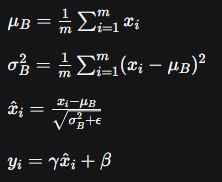

Donde **m** es el tamaño del lote, **ε** es una constante pequeña para evitar división por cero,**γ** y **β** son parámetros aprendibles que permiten que la red pueda recuperar la identidad si es necesario. La normalización por lotes tiene múltiples beneficios: permite usar tasas de aprendizaje más altas porque estabiliza el entrenamiento; reduce el problema de cambio de covariable interna (internal covariate shift), es decir, el hecho de que la distribución de las activaciones cambia durante el entrenamiento; y tiene un efecto regularizante leve, ya que introduce ruido debido a que las estadísticas se calculan sobre el lote y no sobre toda la población.

# Arquitectura de una CNN

## Estructura General y Patrón de Diseño

Una arquitectura de CNN típica sigue un patrón bien definido que se repite varias veces: primero una capa convolucional, luego una activación ReLU, luego una capa de pooling, y este bloque se repite una o más veces. Después de varios de estos bloques, los mapas de características se aplanan (flatten) en un vector unidimensional, y finalmente se conectan una o más capas densas (fully connected) que terminan en una capa de salida con softmax para clasificación o activación lineal para regresión.

Una forma mejor de entenderlo sería hacer un ejemplo concreto aplicado al dataset CIFAR-10, que contiene imágenes a color de 32×32 píxeles con 3 canales (rojo, verde, azul) y 10 clases diferentes (aviones, automóviles, pájaros, gatos, etc.). ¿Cómo sería la arquitectura?

La entrada tiene dimensiones 32×32×3 (alto, ancho, canales). Aplicamos una capa convolucional con 32 filtros de 3×3 y padding "same", lo que produce una salida de 32×32×32. Luego aplicamos ReLU y un max pooling con ventana 2×2 y stride 2, reduciendo las dimensiones espaciales a 16×16 (porque 32/2 = 16), manteniendo los 32 canales. En este punto tenemos un tensor de 16×16×32

Repetimos el proceso con una segunda capa convolucional, ahora con 64 filtros de 3×3 y padding "same", obteniendo 16×16×64. Aplicamos ReLU y otro max pooling 2×2, reduciendo a 8×8×64. Añadimos una tercera capa convolucional con 128 filtros, obteniendo 8×8×128, seguida de ReLU y max pooling, reduciendo a 4×4×128

Ahora tenemos un tensor de 4×4×128, que equivale a 4×4×128 = 2048 números. Aplanamos esto en un vector de 2048 elementos y lo conectamos a una capa densa con 256 neuronas y activación ReLU. Para evitar sobreajuste, aplicamos dropout con una tasa de 0.5 (es decir, durante el entrenamiento se desactiva aleatoriamente el 50% de las neuronas en cada iteración). Finalmente, conectamos esta capa a la capa de salida con 10 neuronas y activación softmax, que produce una distribución de probabilidad sobre las 10 clases

## Cálculo del Número de Parámetros
Una de las ventajas más importantes de las CNN es la reducción masiva en el número de parámetros comparado con redes densas. Calculemos cuántos parámetros tiene la arquitectura que acabamos de describir.

En la primera capa convolucional, tenemos 32 filtros de 3×3 aplicados sobre 3 canales de entrada. Cada filtro tiene 3×3×3 = 27 pesos más 1 sesgo, totalizando 28 parámetros por filtro. Multiplicando por 32 filtros obtenemos 896 parámetros. La segunda capa convolucional tiene 64 filtros de 3×3 aplicados sobre 32 canales de entrada, así que cada filtro tiene 3×3×32 = 288 pesos más 1 sesgo, totalizando 289 por filtro, y 289×64 = 18,496 parámetros. La tercera capa convolucional tiene 128 filtros de 3×3 aplicados sobre 64 canales, dando 3×3×64 = 576 pesos más 1 sesgo = 577 por filtro, y 577×128 = 73,856 parámetros.

La primera capa densa conecta la entrada aplanada de 2048 neuronas con 256 neuronas, lo que da 2048×256 = 524,288 pesos más 256 sesgos, totalizando 524,544 parámetros. La capa final conecta 256 neuronas con 10, dando 256×10 = 2,560 pesos más 10 sesgos = 2,570 parámetros.

Sumando todo, tenemos 896 + 18,496 + 73,856 + 524,544 + 2,570 = 620,362 parámetros. Esto parece una cantidad grande, pero si comparamos con una red densa que procesara la misma imagen de 32×32×3 = 3072 entradas, y tuviera una capa oculta de 256 neuronas, ya tendríamos 3072×256 ≈ 786,000 parámetros solo en la primera capa, sin contar las capas convolucionales y el resto de la arquitectura. La CNN logra un número similar de parámetros pero con una estructura mucho más expresiva y con la capacidad de explotar la estructura espacial de la imagen.

# Entrenamiento de CNN

## Retropropagación en capas convolucionales (backpropagation)

El entrenamiento de las CNN utiliza el mismo algoritmo de retropropagación (backpropagation) que las redes densas, pero adaptado a las operaciones de convolución y pooling. La idea fundamental es calcular el gradiente de la función de pérdida con respecto a cada parámetro (los pesos de los filtros) y luego actualizar esos parámetros en la dirección opuesta al gradiente para minimizar la pérdida.

Para una capa convolucional, la retropropagación requiere dos cálculos principales. Primero, el gradiente con respecto a los filtros: cada peso del filtro contribuye a muchas posiciones en la salida (tantas como veces se aplicó el filtro sobre la entrada). Por lo tanto, el gradiente de un peso específico se calcula sumando las contribuciones de todas las posiciones donde ese peso se multiplicó con algún valor de entrada. En la práctica, este cálculo se implementa como una convolución entre la entrada y el gradiente de la salida.

Segundo, necesitamos propagar el gradiente hacia atrás a la capa anterior, es decir, calcular cómo afectan los cambios en la entrada a la pérdida final. Esto se logra mediante una operación llamada convolución transpuesta o de-correlación cruzada (cross-correlation), que esencialmente es equivalente a aplicar la convolución con el filtro rotado 180 grados sobre el gradiente de la salida.

Para las capas de pooling, la retropropagación es más simple. En el max pooling, durante el pase hacia adelante recordamos en qué posición de cada ventana se encontraba el valor máximo. Durante el pase hacia atrás, el gradiente se asigna completamente a esa posición, y cero a las demás posiciones de la ventana. En el average pooling, el gradiente se distribuye uniformemente entre todas las posiciones de la ventana.

## Funciones de Pérdida y Optimizadores

La función de pérdida más común para problemas de clasificación multiclase es la entropía cruzada (cross-entropy). Para una muestra con etiqueta verdadera y (representada como un vector one-hot, es decir, un vector con un 1 en la posición de la clase correcta y 0 en las demás) y predicción ŷ (la salida de softmax), la pérdida se define como:

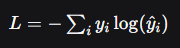

Para problemas de clasificación binaria, se usa la entropía cruzada binaria: 

![image.png](cnn/cbinaria.png)

Para problemas de regresión (predicción de un valor continuo), se suele usar el error cuadrático medio (MSE, Mean Squared Error):

![image.png](cnn/regresion.png)

En cuanto a los optimizadores, el más simple es el descenso de gradiente estocástico (SGD) con momento. El momento es una técnica que acumula los gradientes pasados para suavizar las actualizaciones y acelerar la convergencia en direcciones consistentes. La actualización con momento se define como

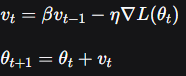

Donde v es la velocidad (acumulado de gradientes), β es el coeficiente de momento (típicamente 0.9), η es la tasa de aprendizaje, y ∇L es el gradiente de la pérdida.

El optimizador más popular actualmente es Adam (Adaptive Moment Estimation), que combina las ventajas del momento y de la adaptación de la tasa de aprendizaje por parámetro. Adam mantiene dos estadísticas: el primer momento (la media de los gradientes) y el segundo momento (la media de los cuadrados de los gradientes). Luego corrige el sesgo inicial y actualiza los parámetros con:

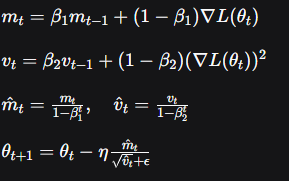

Adam es muy robusto y funciona bien con una amplia variedad de problemas sin necesidad de ajustar mucho la tasa de aprendizaje. Los valores típicos son β₁ = 0.9, β₂ = 0.999, η = 0.001.

## Estrategias de Regularización

El sobreajuste (overfitting) es un problema común en CNN, especialmente cuando se tienen pocos datos de entrenamiento. Las técnicas de regularización ayudan a mitigar este problema. La más sencilla es la regularización L2 (también llamada decaimiento de pesos), que añade un término a la función de pérdida que penaliza los pesos grandes:

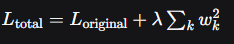

Donde λ es un hiperparámetro que controla la fuerza de la regularización.

Otra técnica muy efectiva es el dropout, propuesto por Hinton y sus colaboradores. Durante el entrenamiento, dropout desactiva aleatoriamente una fracción p de las neuronas en cada iteración (típicamente p = 0.5). Esto fuerza a la red a aprender representaciones redundantes, ya que no puede depender de la presencia de ninguna neurona específica. En la práctica, se implementa multiplicando la salida de la capa por una máscara de Bernoulli y luego, durante la inferencia, se multiplica por (1-p) para mantener la escala esperada.

El early stopping es otra forma de regularización que no modifica el modelo ni la función de pérdida, sino el procedimiento de entrenamiento. Consiste en monitorear la pérdida en un conjunto de validación y detener el entrenamiento cuando esta pérdida deja de mejorar durante varias épocas, incluso si la pérdida en entrenamiento sigue disminuyendo. Esto evita que el modelo memorice ruido en los datos de entrenamiento.

Por último, el data augmentation es quizás la técnica más poderosa cuando se dispone de pocos datos. Consiste en aplicar transformaciones aleatorias a las imágenes de entrenamiento para generar ejemplos adicionales de forma virtual. Algunas transformaciones comunes incluyen rotaciones aleatorias (entre -15° y 15°), desplazamientos horizontales y verticales (hasta un 10% del tamaño de la imagen), volteos horizontales (espejo), cambios de brillo y contraste, zoom aleatorio y adición de ruido gaussiano. Estas transformaciones deben ser realistas: por ejemplo, en un problema de clasificación de dígitos manuscritos, rotar un 6 en 180 grados lo convertiría en un 9, lo cual no sería una transformación válida porque cambia la clase.

# Arquitecturas Clásicas de una CNN

## LeNet-5 (1998)
Fue la primera CNN exitosa y se utilizó para reconocer dígitos manuscritos en el dataset MNIST. Desarrollada por Yann LeCun en los laboratorios Bell, esta arquitectura estableció muchos de los principios que aún se usan hoy. Su arquitectura consta de siete capas (sin contar la entrada). Primero, una capa convolucional con 6 filtros de 5×5 que convierte la imagen de entrada de 32×32×1 en 6 mapas de características de 28×28. Luego, una capa de average pooling (aunque LeCun llamaba a esto "submuestreo") con ventana 2×2 y stride 2 reduce el tamaño a 14×14. Sigue una segunda capa convolucional con 16 filtros de 5×5 que produce 16 mapas de 10×10 (aplicando la convolución solo sobre algunas combinaciones de los mapas de entrada, no sobre todos, por eficiencia computacional). Luego otro average pooling reduce a 5×5. Luego una capa convolucional con 120 filtros de 5×5 que produce un vector de 120 elementos (pues 5×5×1×120, pero aquí ya no hay pooling). Finalmente, dos capas densas: una de 84 neuronas con activación tangente hiperbólica y una de salida de 10 neuronas con activación softmax. LeNet-5 logró una precisión del 99.2% en MNIST, un resultado impresionante para su época.

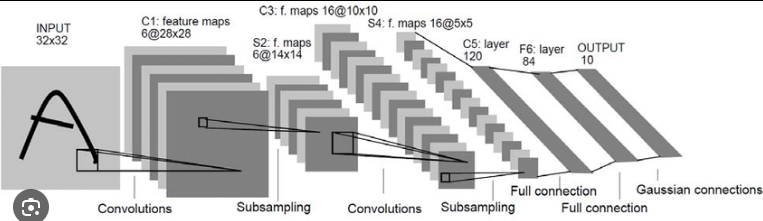


## AlexNet (2012)

Marcó un antes y después en el campo de la visión por computadora al ganar el concurso ImageNet 2012 por un margen significativo. Esta arquitectura fue la primera en demostrar que las CNN podían escalar a datasets masivos (ImageNet tiene 1.2 millones de imágenes etiquetadas en 1000 clases). AlexNet tiene 60 millones de parámetros y consta de 8 capas: 5 convolucionales y 3 densas. Innovaciones importantes de AlexNet incluyen: el uso de ReLU como activación (en lugar de tanh), que aceleró el entrenamiento; dropout en las capas densas para reducir sobreajuste; data augmentation mediante recortes aleatorios y volteos horizontales; y el uso de dos GPUs en paralelo debido a que la memoria de la época era insuficiente para entrenar el modelo completo en una sola GPU. La arquitectura específica tiene capas convolucionales con 96, 256, 384, 384 y 256 filtros respectivamente, con tamaños de kernel de 11×11 (primera capa, con stride 4), 5×5 (segunda capa) y 3×3 (capas restantes). El tamaño de entrada es de 227×227×3.

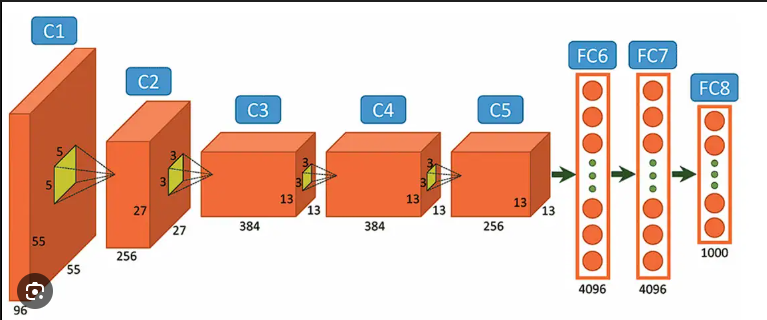

## VGGNet (2014)
Desarrollada por el grupo de Oxford Visual Geometry Group, demostró que la profundidad de la red es un factor crítico para el rendimiento. La arquitectura VGG-16 (16 capas) y VGG-19 (19 capas) utilizan un diseño extremadamente uniforme: solo filtros de 3×3 y max pooling 2×2, apilando más capas convolucionales para aumentar la profundidad. La idea detrás de usar filtros pequeños pero muchos es que dos capas convolucionales de 3×3 tienen un campo receptivo efectivo de 5×5 (porque la salida de la primera capa combina información de 3×3, y la segunda capa combina esas salidas, abarcando efectivamente una región de 5×5), pero con menos parámetros que una capa de 5×5 (2×3×3×canales² vs 5×5×canales²). Tres capas de 3×3 dan un campo receptivo de 7×7 con aún menos parámetros. VGG-16 tiene aproximadamente 138 millones de parámetros, la mayoría en las capas densas finales. Aunque es costosa computacionalmente, VGG sigue siendo popular por su simplicidad y por los excelentes mapas de características que produce, que se usan comúnmente para transfer learning.

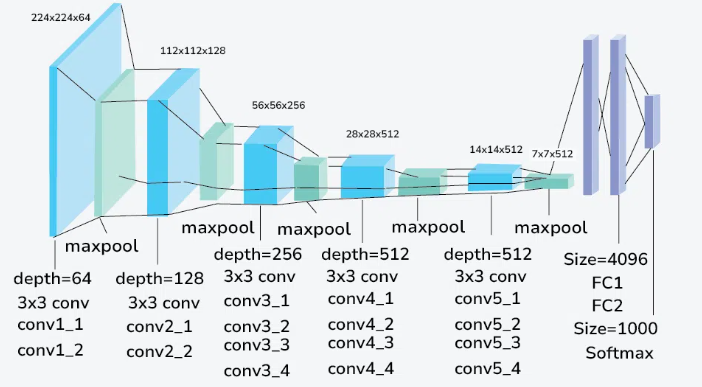


## ResNet (2015)

ResNet (Residual Network) resolvió uno de los problemas más importantes del aprendizaje profundo: ¿cómo entrenar redes extremadamente profundas sin que el gradiente desaparezca o explote? La solución de Kaiming He fue introducir conexiones residuales o skip connections. En un bloque residual, en lugar de aprender directamente la función deseada H(x) (mapeo de entrada x a salida), la red aprende el residuo F(x) = H(x) - x, y luego la salida es F(x) + x. Esto parece un cambio pequeño, pero tiene un impacto enorme. Si la función óptima es la identidad (H(x)=x), entonces aprender F(x)=0 es mucho más fácil que aprender directamente la identidad. Más importante aún, las conexiones residuales proporcionan un camino directo para que el gradiente fluya a través de la red sin atenuarse, permitiendo entrenar redes con más de 100 e incluso 1000 capas.

La arquitectura ResNet-50 (50 capas) es una de las más utilizadas. Utiliza bloques "bottleneck" que primero reducen el número de canales con una convolución 1×1, luego aplican una convolución 3×3, y finalmente expanden nuevamente con otra convolución 1×1. Esto reduce la cantidad de parámetros y cómputo. ResNet-152 tiene 152 capas y fue el estado del arte en ImageNet 2015.

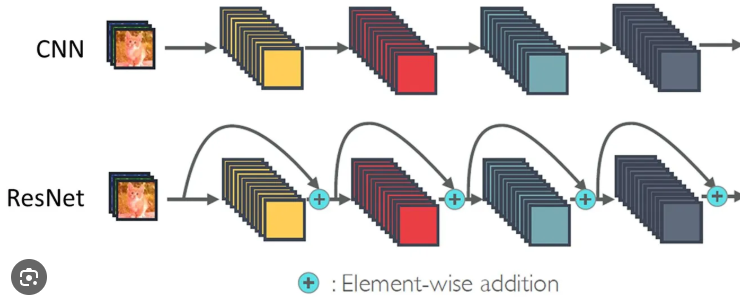

## Arquitecturas Modernas y Eficientes
Posteriormente surgieron arquitecturas como Inception (GoogLeNet), que utiliza módulos que aplican múltiples tamaños de kernel en paralelo (1×1, 3×3, 5×5) y luego concatenan los resultados; DenseNet, donde cada capa se conecta con todas las capas siguientes (conexiones densas), lo que mejora el flujo de gradiente y reduce la cantidad de parámetros; MobileNet, diseñada para dispositivos móviles usando convoluciones separables en profundidad (depthwise separable convolutions) que reducen drásticamente el cómputo; y EfficientNet, que escala sistemáticamente la profundidad, el ancho y la resolución de la red para lograr un rendimiento óptimo con recursos limitados.


# Transfer Learning y Fine-tuning

## ¿Qué es el Transfer Learning y por qué funciona?

Es una técnica que consiste en tomar un modelo preentrenado en un dataset grande y diverso (como ImageNet, que tiene 1.2 millones de imágenes de 1000 categorías) y reutilizarlo para una tarea distinta, generalmente con muchos menos datos. Esta técnica funciona porque las primeras capas de una CNN aprenden características muy generales (bordes, esquinas, textures, patrones de color)que son útiles para prácticamente cualquier tarea de visión por computadora. Las capas medias aprenden patrones más específicos como partes de objetos (ruedas, ojos, alas), y las últimas capas aprenden combinaciones de estas partes que son específicas de las clases del dataset original

## Estrategias de transfer learning

Hay tres estrategias principales, que se eligen según el tamaño del dataset de destino y su similitud con ImageNet.

**1.** Uso del modelo como extractor de características fijo (feature extraction). En este caso, congelamos todas las capas convolucionales (es decir, no permitimos que se actualicen durante el entrenamiento) y solo entrenamos una nueva capa clasificadora (una o más capas densas) encima. Esta estrategia funciona bien cuando el dataset de destino es pequeño (menos de unos pocos miles de imágenes) o cuando es muy similar a ImageNet. La extracción de características es muy rápida porque podemos precomputar las características para todas las imágenes (pasar las imágenes por la CNN congelada una sola vez y guardar las activaciones) y luego entrenar solo el clasificador.

**2.** Fine-tuning completo. En este caso, descongelamos todas o algunas de las capas convolucionales y continuamos entrenando toda la red con una tasa de aprendizaje muy baja (típicamente 10 veces más pequeña que la usada para entrenar desde cero). Esto permite que los pesos se adapten a las particularidades del nuevo dataset. El fine-tuning funciona bien cuando el dataset de destino es grande (más de 10,000 imágenes) o cuando es significativamente diferente de ImageNet (por ejemplo, imágenes médicas, imágenes de satélite, o dominios muy especializados). Para evitar dañar las características aprendidas, se suele hacer fine-tuning en etapas: primero entrenar solo el clasificador por unas épocas, luego descongelar las últimas capas convolucionales y entrenar con tasa de aprendizaje baja, y finalmente, si se tiene muchos datos, descongelar todas las capas.

**3.** Entrenar desde cero, que solo es recomendable cuando se tiene un dataset muy grande (al menos varios cientos de miles de imágenes) y cuando el dominio es extremadamente diferente de ImageNet. En la mayoría de los casos prácticos, el transfer learning con fine-tuning supera al entrenamiento desde cero, incluso cuando se tienen datasets de tamaño moderado.


<div style="display:flex; justify-content:center; align-items:center; margin:25px 0;">
    
![image.png](cnn/tra.avif)

</div>

## Modelos preentrenados disponibles

Los frameworks de deep learning proporcionan fácil acceso a muchos modelos preentrenados. En PyTorch, se pueden cargar con torchvision.models, mientras que en Keras están disponibles en tensorflow.keras.applications. Algunos de los modelos más útiles son:

ResNet (resnet18, resnet34, resnet50, resnet101, resnet152) es excelente para la mayoría de las tareas por su buen equilibrio entre rendimiento y velocidad. VGG (vgg16, vgg19) produce características muy ricas pero es más pesado. DenseNet (densenet121, densenet169, densenet201) es más eficiente que ResNet en parámetros pero más lento. EfficientNet (B0 a B7) ofrece el mejor rendimiento por unidad de cómputo. MobileNet (mobilenet_v2, mobilenet_v3) es ideal para dispositivos móviles y edge computing.

Cuando se carga un modelo preentrenado, es importante aplicar las mismas normalizaciones que se usaron durante su entrenamiento original. Por ejemplo, los modelos entrenados en ImageNet fueron normalizados con:
- mean = [0.485, 0.456, 0.406]
- std = [0.229, 0.224, 0.225]

Por lo que debemos usar estos mismos valores para nuestras imágenes de entrada.

# Visualización e interpretabilidad

## ¿Por qué necesitamos interpretar CNN?
Uno de los mayores críticas a las redes profundas es que funcionan como una "caja negra": podemos obtener predicciones muy precisas, pero no sabemos por qué la red tomó esa decisión. En aplicaciones críticas como diagnóstico médico, conducción autónoma o justicia penal, es fundamental poder explicar y justificar las decisiones del modelo. Además, la interpretabilidad nos ayuda a depurar el modelo, identificar sesgos, y ganar confianza en que el modelo está aprendiendo las características correctas (y no, por ejemplo, reconociendo el fondo de la imagen en lugar del objeto).

## Visualización de filtros aprendidos

Una de las formas más simples de interpretar una CNN es visualizar los filtros de la primera capa convolucional. Debido a que estos filtros operan directamente sobre los píxeles de la imagen (en escala de grises o colores), son directamente interpretables por humanos. En una CNN entrenada en ImageNet, los filtros de la primera capa suelen parecerse a detectores de bordes en diferentes orientaciones, detectores de patrones de color (rojo-verde, azul-amarillo) y detectores de texturas simples como puntos o líneas. A medida que avanzamos a capas más profundas, los filtros se vuelven más abstractos y difíciles de interpretar directamente, pero se pueden usar técnicas como la descomposición en componentes principales o la visualización de activaciones máximas.

## Mapas de activación y Grad-CAM
Muestran qué regiones de la imagen activan más a cada filtro. Una técnica más poderosa es Grad-CAM (Gradient-weighted Class Activation Mapping), que genera un mapa de calor que resalta las regiones de la imagen que más contribuyen a la decisión de una clase específica.

El funcionamiento de Grad-CAM es el siguiente: tomamos la última capa convolucional (que tiene información espacial de alto nivel) y calculamos el gradiente de la puntuación de la clase objetivo con respecto a los mapas de características de esa capa. Luego, promediamos estos gradientes por canal para obtener pesos que indican la importancia de cada canal. Finalmente, calculamos una combinación lineal ponderada de los mapas de características (usando estos pesos) y aplicamos ReLU para quedarnos solo con las contribuciones positivas. El resultado es un mapa de calor del mismo tamaño que los mapas de características de la última capa convolucional, que luego se redimensiona al tamaño de la imagen original.

Grad-CAM es muy útil para depurar modelos: si estamos clasificando una imagen de un gato pero el mapa de calor resalta principalmente la alfombra o el sofá, eso indica que el modelo ha aprendido una correlación espuria en lugar de las características reales del gato. También se puede usar para explicar decisiones a usuarios no técnicos, superponiendo el mapa de calor sobre la imagen original.

# Aplicaciones prácticas de las CNN

## Clasificación de imágenes

La aplicación más directa y común de las CNN es la clasificación de imágenes, donde el objetivo es asignar una etiqueta a toda la imagen. Ejemplos incluyen clasificación de especies de animales, diagnóstico de enfermedades a partir de radiografías, detección de defectos en manufactura, y moderación de contenido en redes sociales. Para esta tarea, la arquitectura típica termina con una capa softmax que produce una distribución de probabilidad sobre las clases.

## Detección de objetos
La detección de objetos va un paso más allá: no solo clasifica la imagen, sino que localiza los objetos mediante cajas delimitadoras (bounding boxes). Arquitecturas populares incluyen R-CNN (Regions with CNN), que primero propone regiones candidatas y luego las clasifica; YOLO (You Only Look Once), que trata la detección como un problema de regresión y puede procesar imágenes en tiempo real (hasta 30-60 fps); y SSD (Single Shot MultiBox Detector), que combina velocidad y precisión. Estas redes se entrenan con pérdidas que combinan el error de clasificación y el error de localización (por ejemplo, IoU - Intersection over Union).

## Segmentación semántica
La segmentación semántica asigna una clase a cada píxel de la imagen. Esto es útil para conducción autónoma (segmentar carretera, vehículos, peatones), imágenes médicas (segmentar tumores u órganos) y edición de imágenes. La arquitectura más conocida es U-Net, que tiene una estructura de codificador-decodificador con conexiones de salto (skip connections) que permiten recuperar información espacial de alta resolución. El codificador reduce la resolución y aumenta el número de canales (como una CNN clásica), mientras que el decodificador hace lo inverso: aumenta la resolución y reduce los canales, combinando información de las capas correspondientes del codificador para refinar los detalles.

# Limitaciones y Desafío Actuales

A pesar de su éxito, las CNN tienen limitaciones importantes. La primera es la necesidad de grandes cantidades de datos etiquetados. Aunque el transfer learning ayuda, aún se requieren cientos o miles de ejemplos por clase para obtener buen rendimiento, mientras que un humano puede aprender una nueva categoría visual con solo unos pocos ejemplos. Esto ha motivado la investigación en aprendizaje semi-supervisado, aprendizaje auto-supervisado y aprendizaje de pocos ejemplos (few-shot learning).

La segunda limitación es la sensibilidad a transformaciones que no están bien representadas en los datos de entrenamiento. Por ejemplo, una CNN entrenada con imágenes orientadas normalmente puede fallar si se rota la imagen 90 grados, a menos que se haya incluido esa transformación en el data augmentation. Tampoco son inherentemente invariantes a cambios de escala, iluminación o punto de vista. Las cápsulas (capsule networks) son una arquitectura alternativa propuesta por Geoffrey Hinton para abordar este problema, aunque aún no han alcanzado la popularidad de las CNN.

La tercera limitación es la vulnerabilidad a ataques adversariales, como se mencionó anteriormente. Esto es especialmente preocupante en sistemas de seguridad (como reconocimiento facial para acceso a áreas restringidas) y vehículos autónomos (donde un adversario podría pegar un pequeño adhesivo en una señal de stop para que la red la interprete como un límite de velocidad).

La cuarta limitación es el costo computacional y energético. Entrenar una CNN grande (como ResNet-152 o EfficientNet-B7) requiere cientos de horas en múltiples GPUs, consumiendo energía equivalente a varios hogares durante ese tiempo. La inferencia también puede ser costosa, lo que dificulta su despliegue en dispositivos con recursos limitados (edge devices). Arquitecturas como MobileNet y técnicas como cuantización, poda (pruning) y destilación de conocimiento (knowledge distillation) abordan este problema.

Finalmente, las CNN carecen de un razonamiento causal explícito. Pueden aprender correlaciones estadísticas, pero no comprenden relaciones de causa y efecto. Por ejemplo, una CNN entrenada para clasificar imágenes de coches podría aprender que el fondo es pasto (porque la mayoría de los coches en el dataset están en exteriores), y luego fallar al clasificar un coche en un garaje. Abordar esta limitación es un área activa de investigación en la intersección del aprendizaje profundo y la inferencia causal.



# Ejercicio

Construir una red neuronal convolucional desde cero para clasificar imágenes de prendas de vestir en 10 categorías.

## Dataset
Fashion-MNIST contiene 70,000 imágenes en escala de grises de 28x28 píxeles, divididas en 60,000 para entrenamiento y 10,000 para prueba. Las 10 clases son:
0: T-shirt/top, 1: Trouser, 2: Pullover, 3: Dress, 4: Coat, 5: Sandal, 6: Shirt, 7: Sneaker, 8: Bag, 9: Ankle boot

## Actividades
1. Cargar y explorar el dataset
2. Preprocesar los datos (normalizar, redimensionar)
3. Diseñar la arquitectura de la CNN
4. Entrenar el modelo
5. Evaluar el rendimiento
6. Visualizar predicciones y errores
7. (Opcional) Mejorar el modelo con técnicas avanzadas

## Imports y configuración de las semillas

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# Configurar para reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

## Cargamos el Dataset y analizamos

100%|█████████████████████████████████████████████████████████████████████████████| 26.4M/26.4M [00:07<00:00, 3.74MB/s]
100%|██████████████████████████████████████████████████████████████████████████████| 29.5k/29.5k [00:00<00:00, 161kB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 4.42M/4.42M [00:01<00:00, 2.92MB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 5.15k/5.15k [00:00<00:00, 23.6MB/s]


Tamaño del conjunto de entrenamiento: 60000
Tamaño del conjunto de prueba: 10000
Forma de una imagen: torch.Size([1, 28, 28])


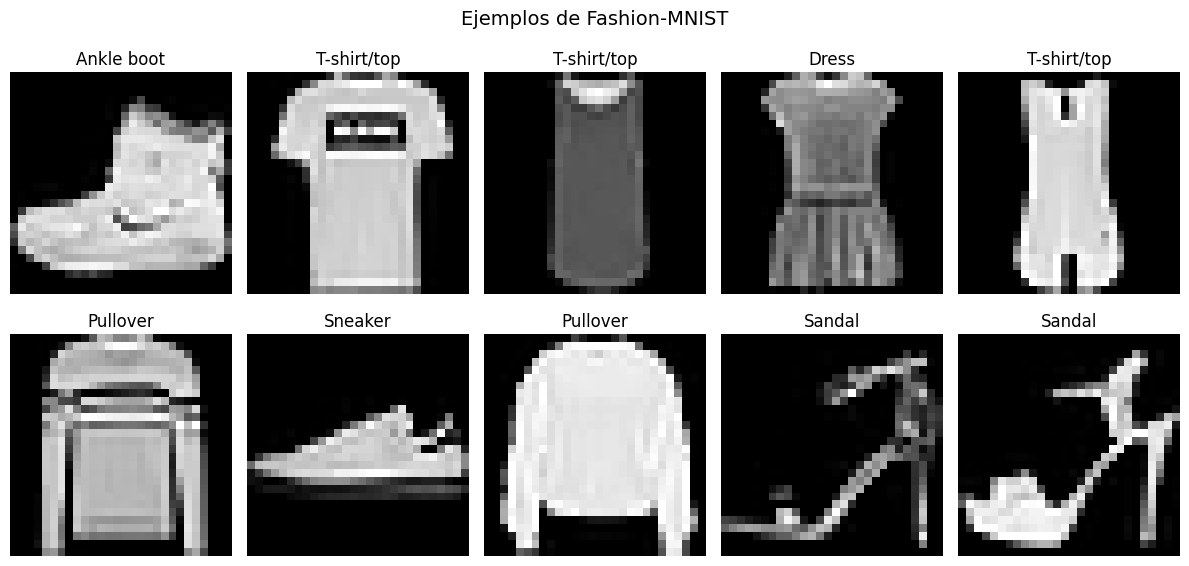

In [8]:
# Transformación: convertir a tensor y normalizar a [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Descargar y cargar datos
train_dataset = datasets.FashionMNIST(
    root='./data', 
    train=True, 
    download=True, 
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root='./data', 
    train=False, 
    download=True, 
    transform=transform
)

# Nombres de las clases
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Tamaño del conjunto de entrenamiento: {len(train_dataset)}")
print(f"Tamaño del conjunto de prueba: {len(test_dataset)}")
print(f"Forma de una imagen: {train_dataset[0][0].shape}")

# Visualizar algunas imágenes
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    image_display = (image.numpy().squeeze() * 0.5) + 0.5
    ax.imshow(image_display, cmap='gray')
    ax.set_title(class_names[label])
    ax.axis('off')
plt.suptitle('Ejemplos de Fashion-MNIST', fontsize=14)
plt.tight_layout()
plt.show()

## Creamos los DataLoaders


In [9]:
# Dividir entrenamiento en train (80%) y validación (20%)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

print(f"Entrenamiento: {len(train_subset)} imágenes")
print(f"Validación: {len(val_subset)} imágenes")
print(f"Prueba: {len(test_dataset)} imágenes")

# Crear DataLoaders
batch_size = 64
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Lotes de entrenamiento: {len(train_loader)}")
print(f"Lotes de validación: {len(val_loader)}")
print(f"Lotes de prueba: {len(test_loader)}")

Entrenamiento: 48000 imágenes
Validación: 12000 imágenes
Prueba: 10000 imágenes
Lotes de entrenamiento: 750
Lotes de validación: 188
Lotes de prueba: 157


## Definimos la Arquitectura para nuestra CNN


In [10]:
class FashionCNN(nn.Module):
    """
    Red CNN para clasificación de Fashion-MNIST.
    Entrada: imágenes de 28x28 en escala de grises (1 canal)
    Salida: 10 clases
    """
    def __init__(self, num_classes=10, dropout_rate=0.25):
        super(FashionCNN, self).__init__()
        
        # Bloque convolucional 1
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        # Bloque convolucional 2
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        # Bloque convolucional 3
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        # Pooling
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Capas fully connected
        # Después de 3 capas de pooling: 28 -> 14 -> 7 -> 3
        # Tamaño final: 3x3 con 128 canales = 1152
        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(256, 128)
        self.dropout2 = nn.Dropout(dropout_rate)
        self.fc3 = nn.Linear(128, num_classes)
    
    def forward(self, x):
        # Bloque 1: Conv -> BN -> ReLU -> Pool
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        
        # Bloque 2: Conv -> BN -> ReLU -> Pool
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        
        # Bloque 3: Conv -> BN -> ReLU -> Pool
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        
        # Aplanar
        x = x.view(x.size(0), -1)
        
        # Capas fully connected
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        
        return x

# Instanciar el modelo
model = FashionCNN().to(device)
print(model)

# Contar parámetros
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal de parámetros: {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,}")

FashionCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1152, out_features=256, bias=True)
  (dropout1): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (dropout2): Dropout(p=0.25, inplace=False)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)

Total de parámetros: 422,474
Parámetros entrenables: 422,474


## Vemos la función de pérdida, el optimizador y el scheduler

In [12]:
# Función de pérdida
criterion = nn.CrossEntropyLoss()

# Optimizador Adam
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Scheduler para reducir learning rate
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

print(f"Learning rate inicial: {learning_rate}")

Learning rate inicial: 0.001


## Función para entrenamiento y evaluación

In [13]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    """Entrena el modelo por una época"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Estadísticas
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc


def evaluate(model, data_loader, criterion, device):
    """Evalúa el modelo en un conjunto de datos"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(data_loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

## Entrenamos el Modelo

In [16]:
num_epochs = 10
train_losses = []
val_losses = []
train_accs = []
val_accs = []

print("Hola, señor. Iniciamos el entrenamiento... piiiii")
print("=" * 60)

for epoch in range(num_epochs):
    # Entrenamiento
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Validación
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    # Actualizar scheduler
    scheduler.step(val_loss)
    
    # Imprimir progreso
    print(f"Epoch {epoch+1:2d}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

print("=" * 60)
print("Entrenamiento completado")

Hola, señor. Iniciamos el entrenamiento... piiiii
Epoch  1/10 | Train Loss: 0.2255 | Train Acc: 91.97% | Val Loss: 0.2347 | Val Acc: 91.78%
Epoch  2/10 | Train Loss: 0.1997 | Train Acc: 92.74% | Val Loss: 0.2314 | Val Acc: 91.86%
Epoch  3/10 | Train Loss: 0.1766 | Train Acc: 93.64% | Val Loss: 0.2334 | Val Acc: 91.52%
Epoch  4/10 | Train Loss: 0.1617 | Train Acc: 94.01% | Val Loss: 0.2903 | Val Acc: 90.33%
Epoch  5/10 | Train Loss: 0.1413 | Train Acc: 94.74% | Val Loss: 0.2259 | Val Acc: 92.59%
Epoch  6/10 | Train Loss: 0.1262 | Train Acc: 95.30% | Val Loss: 0.2500 | Val Acc: 92.22%
Epoch  7/10 | Train Loss: 0.1155 | Train Acc: 95.76% | Val Loss: 0.2381 | Val Acc: 92.53%
Epoch  8/10 | Train Loss: 0.1042 | Train Acc: 96.11% | Val Loss: 0.2523 | Val Acc: 92.71%
Epoch  9/10 | Train Loss: 0.0893 | Train Acc: 96.72% | Val Loss: 0.2724 | Val Acc: 92.29%
Epoch 10/10 | Train Loss: 0.0554 | Train Acc: 97.94% | Val Loss: 0.2724 | Val Acc: 92.88%
Entrenamiento completado


## Ahora veamos las curvas de aprendizaje que obtuvo

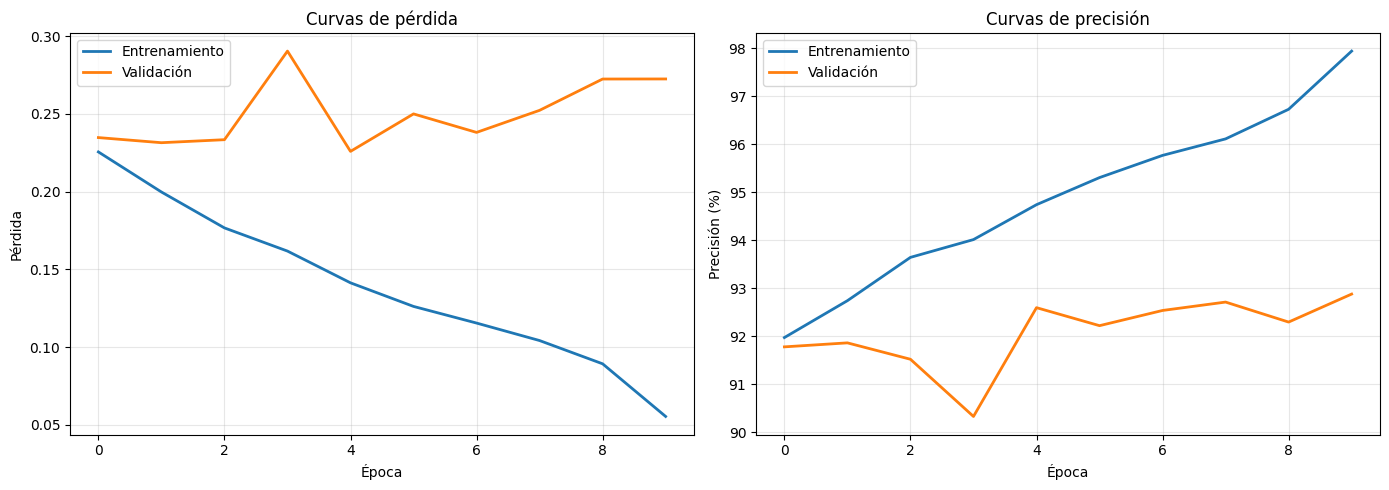

Mejor precisión de validación: 92.88%
Mejor pérdida de validación: 0.2259


In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Curvas de pérdida
ax1.plot(train_losses, label='Entrenamiento', linewidth=2)
ax1.plot(val_losses, label='Validación', linewidth=2)
ax1.set_xlabel('Época')
ax1.set_ylabel('Pérdida')
ax1.set_title('Curvas de pérdida')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Curvas de precisión
ax2.plot(train_accs, label='Entrenamiento', linewidth=2)
ax2.plot(val_accs, label='Validación', linewidth=2)
ax2.set_xlabel('Época')
ax2.set_ylabel('Precisión (%)')
ax2.set_title('Curvas de precisión')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mejor precisión de validación: {max(val_accs):.2f}%")
print(f"Mejor pérdida de validación: {min(val_losses):.4f}")

## Evaluación de los Conjuntos de Prueba

In [18]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"RESULTADOS EN CONJUNTO DE PRUEBA")
print(f"Pérdida: {test_loss:.4f}")
print(f"Precisión: {test_acc:.2f}%")

# Obtener todas las predicciones
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

RESULTADOS EN CONJUNTO DE PRUEBA
Pérdida: 0.3126
Precisión: 92.39%


## Matriz de Confusión

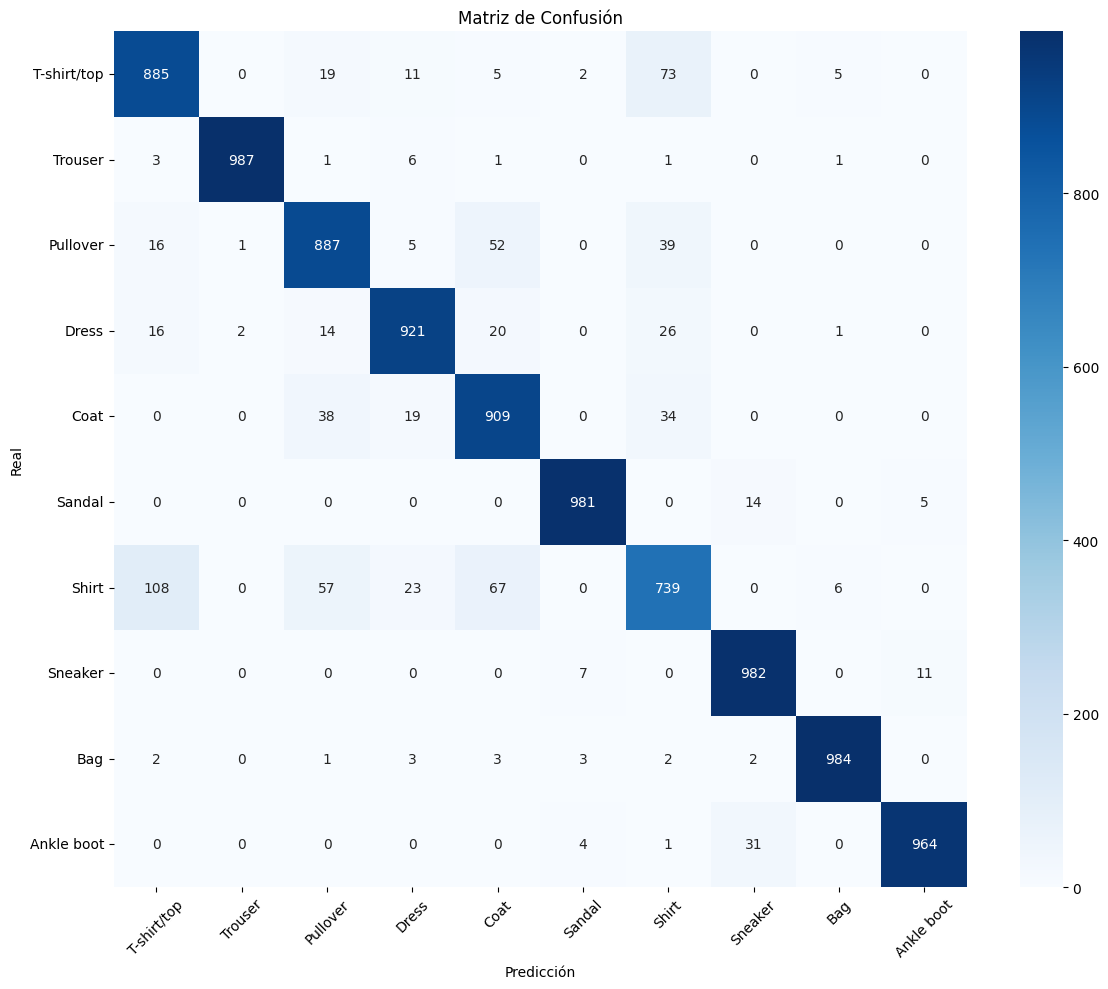

              precision    recall  f1-score   support

 T-shirt/top       0.86      0.89      0.87      1000
     Trouser       1.00      0.99      0.99      1000
    Pullover       0.87      0.89      0.88      1000
       Dress       0.93      0.92      0.93      1000
        Coat       0.86      0.91      0.88      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.81      0.74      0.77      1000
     Sneaker       0.95      0.98      0.97      1000
         Bag       0.99      0.98      0.99      1000
  Ankle boot       0.98      0.96      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



In [19]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Reporte de clasificación
print(classification_report(all_labels, all_preds, target_names=class_names))

## Visualizamos las predicciones

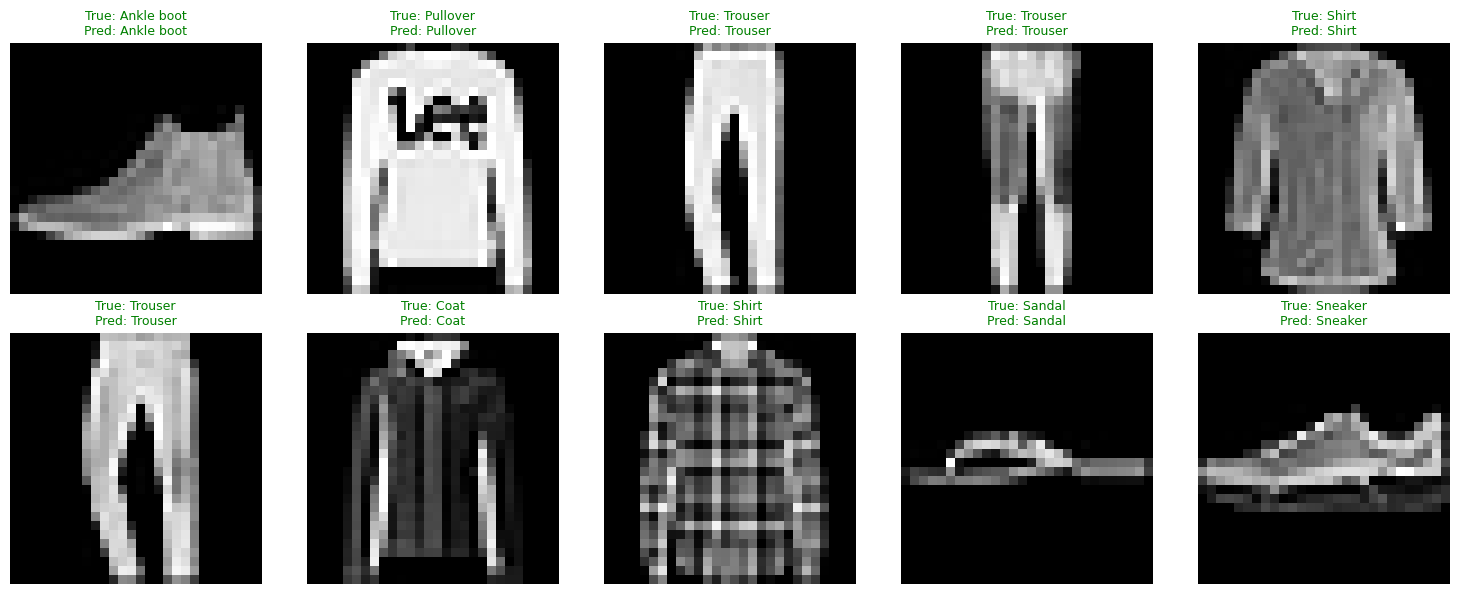

In [20]:
def show_predictions(model, data_loader, class_names, device, num_images=10):
    """Muestra imágenes con sus predicciones"""
    model.eval()
    
    images_shown = 0
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flat
    
    with torch.no_grad():
        for batch_images, batch_labels in data_loader:
            batch_images = batch_images.to(device)
            outputs = model(batch_images)
            _, batch_preds = torch.max(outputs, 1)
            
            for i in range(len(batch_labels)):
                if images_shown >= num_images:
                    break
                
                img = batch_images[i].cpu().squeeze().numpy()
                img_display = (img * 0.5) + 0.5
                true_label = class_names[batch_labels[i]]
                pred_label = class_names[batch_preds[i]]
                is_correct = (batch_labels[i] == batch_preds[i])
                
                color = 'green' if is_correct else 'red'
                title = f"True: {true_label}\nPred: {pred_label}"
                
                axes[images_shown].imshow(img_display, cmap='gray')
                axes[images_shown].set_title(title, color=color, fontsize=9)
                axes[images_shown].axis('off')
                images_shown += 1
            
            if images_shown >= num_images:
                break
    
    plt.tight_layout()
    plt.show()

# Mostrar predicciones
show_predictions(model, test_loader, class_names, device, num_images=10)

## Análisis de Errores

Se encontraron 13 errores (mostrando hasta 12)


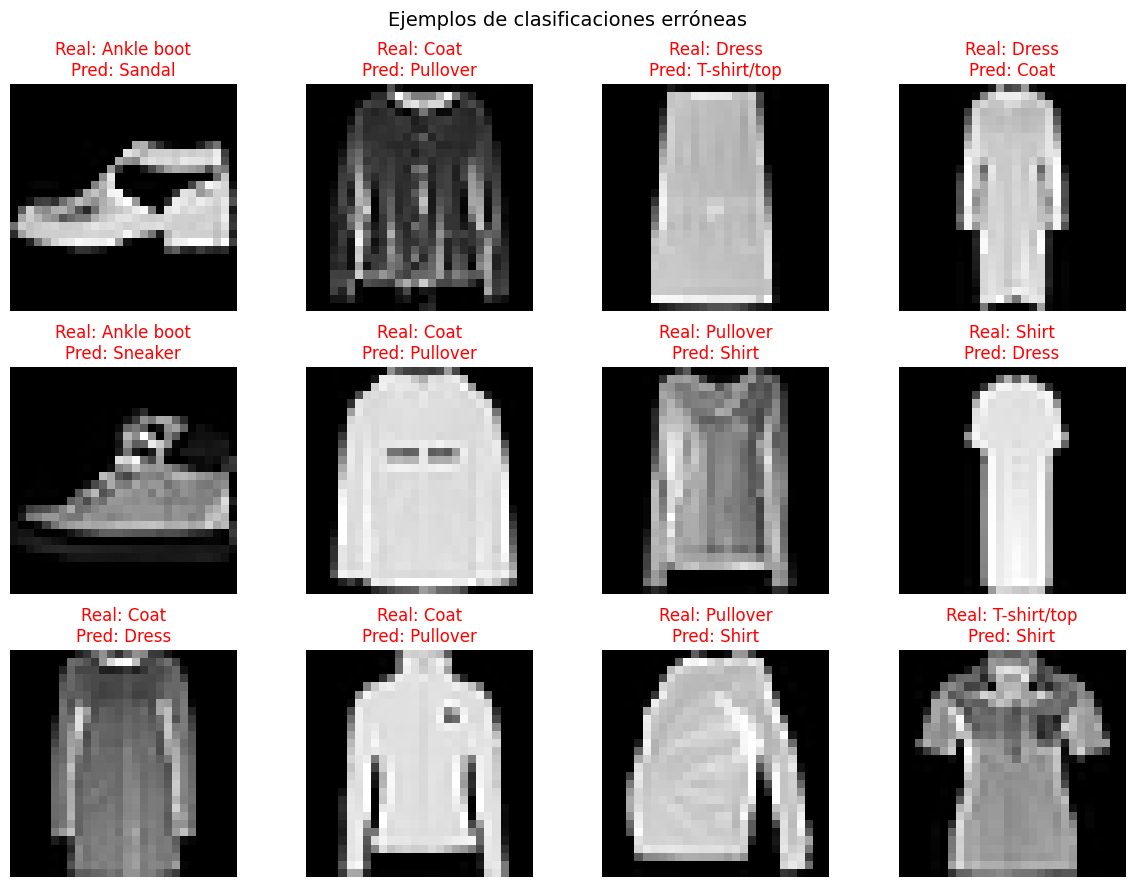

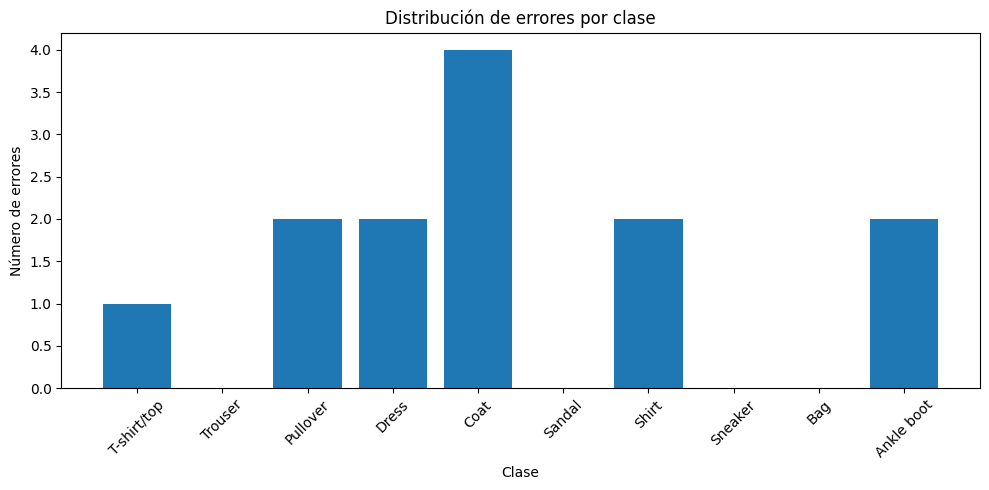

In [21]:
# Encontrar ejemplos donde el modelo se equivocó
model.eval()
errors = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        for i in range(len(labels)):
            if preds[i] != labels[i]:
                img = images[i].cpu().squeeze().numpy()
                img_display = (img * 0.5) + 0.5
                errors.append((img_display, labels[i].item(), preds[i].item()))
        
        if len(errors) >= 12:
            break

print(f"Se encontraron {len(errors)} errores (mostrando hasta 12)")

# Mostrar errores
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
axes = axes.flat

for i, (img, true, pred) in enumerate(errors[:12]):
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Real: {class_names[true]}\nPred: {class_names[pred]}", color='red')
    axes[i].axis('off')

plt.suptitle('Ejemplos de clasificaciones erróneas', fontsize=14)
plt.tight_layout()
plt.show()

# Estadísticas de errores por clase
error_count = np.zeros(10)
for _, true, _ in errors:
    error_count[true] += 1

plt.figure(figsize=(10, 5))
plt.bar(class_names, error_count)
plt.xlabel('Clase')
plt.ylabel('Número de errores')
plt.title('Distribución de errores por clase')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Guardamos el modelo

In [22]:
# Guardar los pesos del modelo
torch.save(model.state_dict(), 'fashion_cnn_model.pth')

# Para cargar el modelo después:
# model = FashionCNN().to(device)
# model.load_state_dict(torch.load('fashion_cnn_model.pth'))
# model.eval()

## Conclusión

In [24]:

print("Conclusión")

print(f"Arquitectura: CNN con 3 capas convolucionales")
print(f"Total de parámetros: {total_params:,}")
print(f"Precisión en prueba: {test_acc:.2f}%")
print(f"Pérdida en prueba: {test_loss:.4f}")


# Identificar mejores y peores clases
per_class_acc = []
for i in range(10):
    mask = np.array(all_labels) == i
    if mask.sum() > 0:
        acc = np.array(all_preds)[mask] == i
        per_class_acc.append(acc.mean() * 100)
    else:
        per_class_acc.append(0)

best_class_idx = np.argmax(per_class_acc)
worst_class_idx = np.argmin(per_class_acc)

print(f"\nMejor clase: {class_names[best_class_idx]} ({per_class_acc[best_class_idx]:.1f}%)")
print(f"Peor clase: {class_names[worst_class_idx]} ({per_class_acc[worst_class_idx]:.1f}%)")

Conclusión
Arquitectura: CNN con 3 capas convolucionales
Total de parámetros: 422,474
Precisión en prueba: 92.39%
Pérdida en prueba: 0.3126

Mejor clase: Trouser (98.7%)
Peor clase: Shirt (73.9%)
